---
title: Character-Level RNN on WikiText-2
category: Deep Learning
tags:
  - deep learning
  - rnn
  - gru
  - language modeling
  - wikitext
  - pytorch
date: 2026-07-31
description: Train a small recurrent language model on WikiText-2 and inspect how sequence state evolves.
aliases:
  - /deep-learning/character-level-rnn-on-wikitext-2
sources:
  - https://huggingface.co/datasets/Salesforce/wikitext
  - https://docs.pytorch.org/tutorials/beginner/nlp/sequence_models_tutorial.html
---

## Goal

Train a small character-level recurrent model on [WikiText-2](https://huggingface.co/datasets/Salesforce/wikitext). We will crop the corpus down to a few hundred thousand characters so the notebook stays laptop-sized while still learning visible local structure.

For a recurrent network,

$$
h_t = f(W_{xh} x_t + W_{hh} h_{t-1} + b_h), \\qquad
\\hat{y}_t = W_{hy} h_t + b_y.
$$

We will use a GRU because it keeps the code compact while still preserving the recurrent inductive bias.


In [1]:
## %pip install -q datasets torch matplotlib

import math
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset

torch.manual_seed(7)
random.seed(7)


/Users/elimelt/Documents/Codex/2026-07-30/github-plugin-github-openai-curated-remote-2/work/notes/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")
train_text = "\n".join(ds["train"]["text"])[:300000]
valid_text = "\n".join(ds["validation"]["text"])[:50000]

vocab = sorted(set(train_text + valid_text))
stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for ch, i in stoi.items()}

train_ids = torch.tensor([stoi[ch] for ch in train_text], dtype=torch.long)
valid_ids = torch.tensor([stoi[ch] for ch in valid_text], dtype=torch.long)

print(f"chars={len(train_ids):,} vocab={len(vocab)}")


chars=300,000 vocab=164


In [3]:
def get_batch(data: torch.Tensor, batch_size: int, block_size: int, device: str):
    starts = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[s : s + block_size] for s in starts]).to(device)
    y = torch.stack([data[s + 1 : s + block_size + 1] for s in starts]).to(device)
    return x, y


class CharRNN(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 64, hidden_dim: int = 128):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.proj = nn.Linear(hidden_dim, vocab_size)

    def forward(self, idx, hidden=None):
        x = self.embed(idx)
        out, hidden = self.rnn(x, hidden)
        logits = self.proj(out)
        return logits, hidden

    @torch.no_grad()
    def generate(self, idx, max_new_tokens: int):
        hidden = None
        for _ in range(max_new_tokens):
            logits, hidden = self(idx[:, -1:], hidden)
            probs = logits[:, -1].softmax(dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_idx], dim=1)
        return idx


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CharRNN(len(vocab)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)

batch_size = 64
block_size = 128
train_losses = []

for step in range(600):
    xb, yb = get_batch(train_ids, batch_size, block_size, device)
    logits, _ = model(xb)
    loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), yb.reshape(-1))
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    train_losses.append(float(loss))

    if step % 200 == 0:
        print(f"step={step:04d} loss={float(loss):.4f}")


/var/folders/89/s5_6m3_s753b66rwdjt2g1lw0000gn/T/ipykernel_21660/2378505179.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  train_losses.append(float(loss))


step=0000 loss=5.1217


step=0200 loss=1.9348


step=0400 loss=1.7522


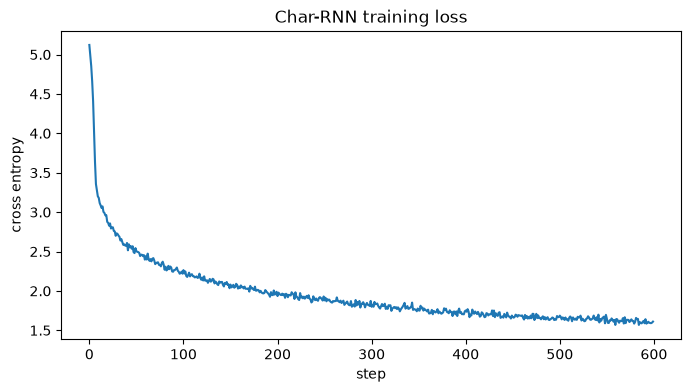

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.title("Char-RNN training loss")
plt.xlabel("step")
plt.ylabel("cross entropy")
plt.show()


In [6]:
start = torch.tensor([[stoi["T"]]], dtype=torch.long, device=device)
sample = model.generate(start, max_new_tokens=600)[0].tolist()
print("".join(itos[i] for i in sample))


The mace often albwoun building texts . It . The Conduabor , and [ @,@ 000 god , 1s ) and won sertic gold dosent exteck operationsious lack tradicated by they was nubind muling continaliginal . The asiggued that worford opecting creatities , the muning its rifle thar , and withlin bypart an troingne of Aprubior , ifter activiled the shiption d. spection . He instinus mopernor plales , and Wather , ḏnyRual in an acterornarder by fuggulatur is reill . In and terall anaway . " A Griate recially sujical towner owerificating buildings tradition in the samited in the 72 @,@ 0000 been larnunes with su


## What To Look For

The model usually learns punctuation, line breaks, and some short-range spelling statistics before it learns anything like semantics. That is exactly the point. The recurrent state is carrying local context forward step by step, and you can see how far that alone gets you.
